In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("../data/prices_round_0_day_-1.csv", delimiter= ";")
df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,5,4998,15,NaN,NaN,5013,5,5014,15,NaN,NaN,5006.0,0.0
1,-1,0,EMERALDS,9992,14,9990,29,NaN,NaN,10008,14,10010,29,NaN,NaN,10000.0,0.0
2,-1,100,EMERALDS,9992,11,9990,22,NaN,NaN,10008,11,10010,22,NaN,NaN,10000.0,0.0
3,-1,100,TOMATOES,5000,8,4998,21,NaN,NaN,5013,8,5014,21,NaN,NaN,5006.5,0.0
4,-1,200,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0


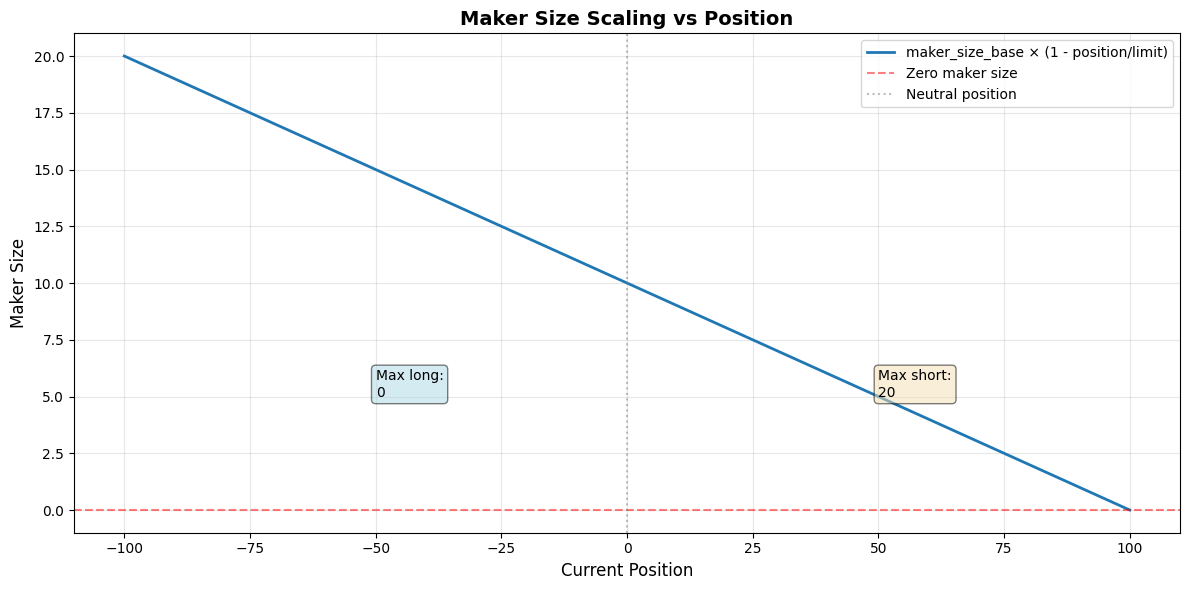

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def plot_maker_size_scaling(maker_size_base: int = 20, position_limit: int = 80):
    """
    Plot how maker_size scales with position.
    
    Args:
        maker_size_base: The base maker size (default from params)
        position_limit: Your position limit (e.g., 100)
    """
    # Generate position range from -limit to +limit
    positions = np.linspace(-position_limit, position_limit, 40)
    
    # Calculate maker_size for each position: maker_size_base * (1 - position/limit)
    maker_sizes = maker_size_base * (1 - positions / position_limit)
    
    # Create the plot
    plt.figure(figsize=(12, 6))
    plt.plot(positions, maker_sizes, linewidth=2, label='maker_size_base × (1 - position/limit)')
    
    # Add reference lines
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Zero maker size')
    plt.axvline(x=0, color='gray', linestyle=':', alpha=0.5, label='Neutral position')
    
    # Labels and formatting
    plt.xlabel('Current Position', fontsize=12)
    plt.ylabel('Maker Size', fontsize=12)
    plt.title('Maker Size Scaling vs Position', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    
    # Add annotations
    plt.text(position_limit * 0.5, maker_size_base * 0.5, 
             f'Max short:\n{maker_size_base * 2:.0f}', 
             fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.text(-position_limit * 0.5, maker_size_base * 0.5, 
             f'Max long:\n0', 
             fontsize=10, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

# Call it with your actual parameters
plot_maker_size_scaling(maker_size_base=10, position_limit=100)

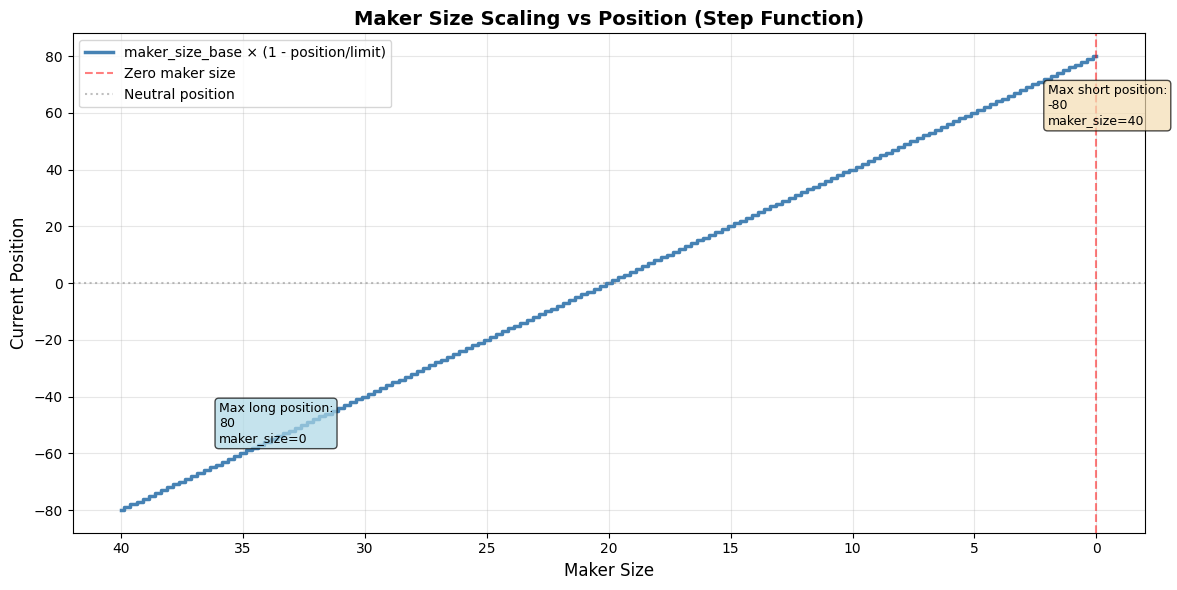

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_maker_size_scaling(maker_size_base: int = 40, position_limit: int = 80):
    """
    Plot how maker_size scales with position (step function).
    
    Args:
        maker_size_base: The base maker size (default from params)
        position_limit: Your position limit (e.g., 80)
    """
    # Generate integer positions from -limit to +limit
    positions = np.arange(-position_limit, position_limit + 1, 1)
    
    # Calculate maker_size for each position: maker_size_base * (1 - position/limit)
    maker_sizes = maker_size_base * (1 - positions / position_limit)
    
    # Create the plot
    plt.figure(figsize=(12, 6))
    plt.step(maker_sizes, positions, where='mid', linewidth=2.5, 
             label='maker_size_base × (1 - position/limit)', color='steelblue')
    
    # Add reference lines
    plt.axvline(x=0, color='r', linestyle='--', alpha=0.5, label='Zero maker size')
    plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5, label='Neutral position')
    
    # Reverse x-axis (high to low)
    plt.gca().invert_xaxis()
    
    # Labels and formatting
    plt.xlabel('Maker Size', fontsize=12)
    plt.ylabel('Current Position', fontsize=12)
    plt.title('Maker Size Scaling vs Position (Step Function)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    
    # Add annotations for extremes
    plt.text(maker_size_base * 0.1, position_limit * 0.7, 
             f'Max short position:\n{-position_limit}\nmaker_size={maker_size_base * 2:.0f}', 
             fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    plt.text(maker_size_base * 1.8, -position_limit * 0.7, 
             f'Max long position:\n{position_limit}\nmaker_size=0', 
             fontsize=9, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    
    plt.tight_layout()
    plt.show()

# Call it with your actual parameters
plot_maker_size_scaling(maker_size_base=20, position_limit=80)

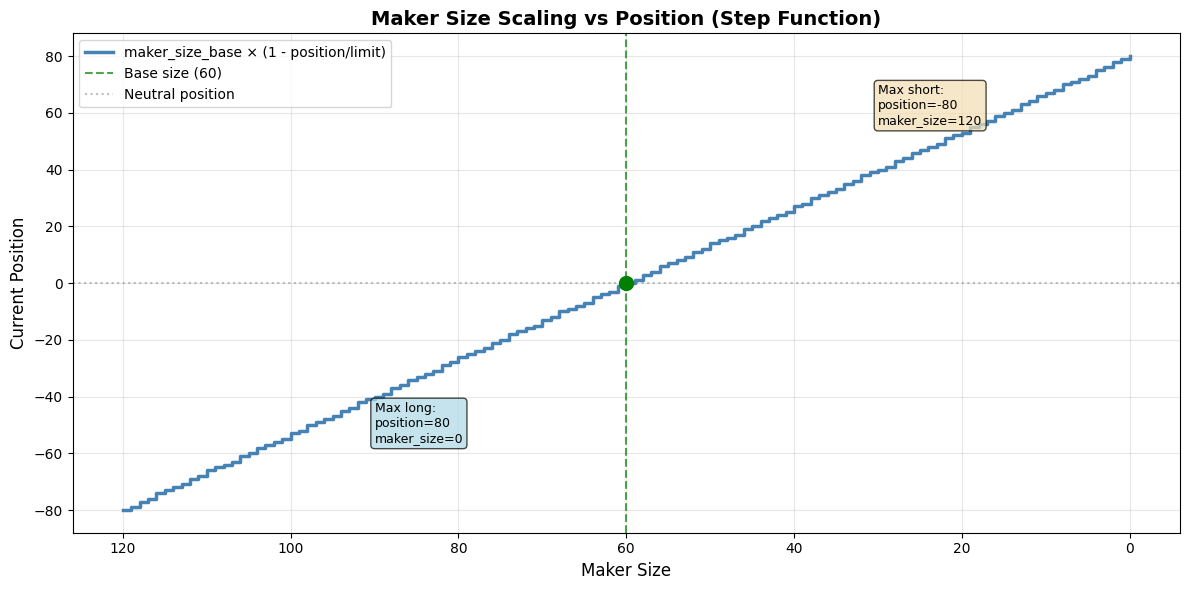

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_maker_size_scaling(maker_size_base: int = 40, position_limit: int = 80):
    """
    Plot how maker_size scales with position (step function with discrete jumps).
    Shows only steps at integer maker_size values.
    
    Args:
        maker_size_base: The base maker size (default from params)
        position_limit: Your position limit (e.g., 80)
    """
    # Generate integer positions from -limit to +limit
    positions = np.arange(-position_limit, position_limit + 1, 1)
    
    # Calculate maker_size for each position: maker_size_base * (1 - position/limit)
    maker_sizes = maker_size_base * (1 - positions / position_limit)
    
    # Round to integers to get discrete steps
    maker_sizes_int = np.round(maker_sizes).astype(int)
    
    # Create the plot
    plt.figure(figsize=(12, 6))
    plt.step(maker_sizes_int, positions, where='post', linewidth=2.5, 
             label='maker_size_base × (1 - position/limit)', color='steelblue')
    
    # Add reference lines
    plt.axvline(x=maker_size_base, color='g', linestyle='--', alpha=0.7, label=f'Base size ({maker_size_base})')
    plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5, label='Neutral position')
    
    # Reverse x-axis (high to low)
    plt.gca().invert_xaxis()
    
    # Labels and formatting
    plt.xlabel('Maker Size', fontsize=12)
    plt.ylabel('Current Position', fontsize=12)
    plt.title('Maker Size Scaling vs Position (Step Function)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    
    # Add annotations for key points
    plt.plot(maker_size_base, 0, 'go', markersize=10)
    
    plt.text(maker_size_base * 0.5, position_limit * 0.7, 
             f'Max short:\nposition={-position_limit}\nmaker_size={maker_size_base * 2:.0f}', 
             fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    plt.text(maker_size_base * 1.5, -position_limit * 0.7, 
             f'Max long:\nposition={position_limit}\nmaker_size=0', 
             fontsize=9, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    
    plt.tight_layout()
    plt.show()

# Call it with your actual parameters
plot_maker_size_scaling(maker_size_base=60, position_limit=80)

In [14]:
import plotly.graph_objects as go
import numpy as np

def plot_maker_size_scaling_plotly(maker_size_base: int = 40, maker_size_base2: int = None, position_limit: int = 80):
    """
    Plot how maker_size scales with position (step function with interactive hover).
    Compare two different maker_size_base values.
    
    Args:
        maker_size_base: The first base maker size (default from params)
        maker_size_base2: The second base maker size for comparison (optional)
        position_limit: Your position limit (e.g., 80)
    """
    # Generate integer positions from -limit to +limit
    positions = np.arange(-position_limit, position_limit + 1, 1)
    
    # Calculate maker_size for each position: maker_size_base * (1 - position/limit)
    maker_sizes = maker_size_base * (1 - positions / position_limit)
    maker_sizes_int = np.round(maker_sizes).astype(int)
    
    # Create the plot
    fig = go.Figure()
    
    # Add first curve
    fig.add_trace(go.Scatter(
        x=maker_sizes_int,
        y=positions,
        mode='lines',
        line=dict(color='steelblue', width=2.5),
        name=f'maker_size_base = {maker_size_base}',
        hovertemplate='<b>Position:</b> %{y}<br><b>Maker Size:</b> %{x}<extra></extra>'
    ))
    
    # Add second curve if provided
    if maker_size_base2 is not None:
        maker_sizes2 = maker_size_base2 * (1 - positions / position_limit)
        maker_sizes_int2 = np.round(maker_sizes2).astype(int)
        
        fig.add_trace(go.Scatter(
            x=maker_sizes_int2,
            y=positions,
            mode='lines',
            line=dict(color='coral', width=2.5),
            name=f'maker_size_base = {maker_size_base2}',
            hovertemplate='<b>Position:</b> %{y}<br><b>Maker Size:</b> %{x}<extra></extra>'
        ))
    
    # Add base size reference lines
    fig.add_vline(
        x=maker_size_base,
        line_dash="dash",
        line_color="steelblue",
        annotation_text=f"Base size 1 ({maker_size_base})",
        annotation_position="top"
    )
    
    if maker_size_base2 is not None:
        fig.add_vline(
            x=maker_size_base2,
            line_dash="dash",
            line_color="coral",
            annotation_text=f"Base size 2 ({maker_size_base2})",
            annotation_position="top"
        )
    
    # Add neutral position reference line
    fig.add_hline(
        y=0,
        line_dash="dot",
        line_color="gray",
        annotation_text="Neutral position",
        annotation_position="right"
    )
    
    # Add base point markers
    fig.add_trace(go.Scatter(
        x=[maker_size_base],
        y=[0],
        mode='markers',
        marker=dict(color='steelblue', size=10),
        name=f'Base point 1 (pos=0)',
        hovertemplate='<b>Position:</b> 0<br><b>Maker Size:</b> ' + str(maker_size_base) + '<extra></extra>'
    ))
    
    if maker_size_base2 is not None:
        fig.add_trace(go.Scatter(
            x=[maker_size_base2],
            y=[0],
            mode='markers',
            marker=dict(color='coral', size=10),
            name=f'Base point 2 (pos=0)',
            hovertemplate='<b>Position:</b> 0<br><b>Maker Size:</b> ' + str(maker_size_base2) + '<extra></extra>'
        ))
    
    # Update layout
    fig.update_layout(
        title='Maker Size Scaling vs Position (Step Function)',
        xaxis_title='Maker Size',
        yaxis_title='Current Position',
        hovermode='closest',
        template='plotly_white',
        width=1200,
        height=600,
        xaxis=dict(autorange='reversed'),
        showlegend=True,
    )
    
    fig.show()

# Call it with your actual parameters
plot_maker_size_scaling_plotly(maker_size_base=40, maker_size_base2=60, position_limit=80)